# Applications of AI

# Final Project

## Diabetes Health Indicators Classification

## Part 2: Model Development & Evaluation

### Marianna Kanellaki - S-001081

This notebook covers TODO

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from torch.utils.data import DataLoader, TensorDataset
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import xgboost as xgb
import seaborn as sns
import pandas as pd
import numpy as np
import kagglehub
import random
import optuna
import torch
import os

/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True

### Dataset Download

In [4]:
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
print("Path to dataset files:", path)
print("\nFiles in dataset:")
print(os.listdir(path))

Path to dataset files: /home/marianna/.cache/kagglehub/datasets/alexteboul/diabetes-health-indicators-dataset/versions/1

Files in dataset:
['diabetes_binary_5050split_health_indicators_BRFSS2015.csv', 'diabetes_binary_health_indicators_BRFSS2015.csv', 'diabetes_012_health_indicators_BRFSS2015.csv']


In [5]:
df = pd.read_csv(path+"/diabetes_012_health_indicators_BRFSS2015.csv")
df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [6]:
# clean types according to kaggle description

boolean_cols = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'
]

categorical_cols = [
    'Diabetes_012',
    'GenHlth',       # 1-5 scale
    'Age',           # 13-level age category
    'Education',     # 1-6 education levels
    'Income'         # 1-8 income brackets
] + boolean_cols # will treat boolean as categorical

integer_cols = [
    'BMI',           # Body Mass Index
    'MentHlth',      # Days of poor mental health in past 30 days
    'PhysHlth'       # Days of poor physical health in past 30 days
]

df[categorical_cols] = df[categorical_cols].astype(int).astype('category')
df[integer_cols] = df[integer_cols].astype(int)

target = 'Diabetes_012'
cat_features = [col for col in categorical_cols if col != target]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   Diabetes_012          253680 non-null  category
 1   HighBP                253680 non-null  category
 2   HighChol              253680 non-null  category
 3   CholCheck             253680 non-null  category
 4   BMI                   253680 non-null  int64   
 5   Smoker                253680 non-null  category
 6   Stroke                253680 non-null  category
 7   HeartDiseaseorAttack  253680 non-null  category
 8   PhysActivity          253680 non-null  category
 9   Fruits                253680 non-null  category
 10  Veggies               253680 non-null  category
 11  HvyAlcoholConsump     253680 non-null  category
 12  AnyHealthcare         253680 non-null  category
 13  NoDocbcCost           253680 non-null  category
 14  GenHlth               253680 non-nul

#### Dataset Split

In [7]:
X = df.drop(columns=['Diabetes_012'])
y = df['Diabetes_012']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp)


In [8]:
# prepare cross validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

In [9]:
# prepare dictionaries for scoring metrics

multiclass_scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro'),
    'roc_auc': make_scorer(roc_auc_score, response_method='predict_proba', multi_class='ovr')
}

binary_scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro'),
    'roc_auc': make_scorer(roc_auc_score, response_method='predict_proba')
}

### XGBoost Feature Importance

/tmp/ipykernel_6505/1957597232.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


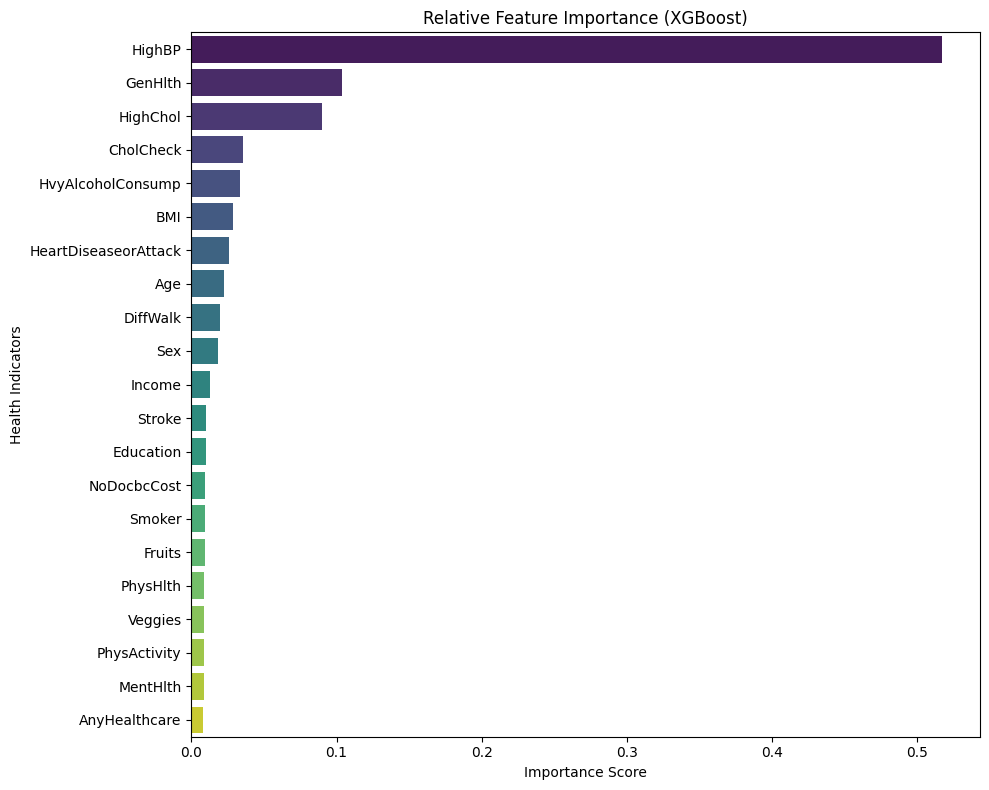

In [10]:
# quick XGBoost model just to evaluate the features
xgb_selector = xgb.XGBClassifier(
    objective='multi:softmax', 
    num_class=3,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
xgb_selector.fit(X_train, y_train)

# extract and sort feature importances
importances = xgb_selector.feature_importances_
feature_names = X_train.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# plot feature importance
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Relative Feature Importance (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Health Indicators')
plt.tight_layout()
plt.savefig('fig_feature_imp.png', dpi=300)
plt.show()

# select the 16 most important features
top_features = feature_imp_df['Feature'].head(16).tolist()

X_train_clean = X_train[top_features]
X_test_clean = X_test[top_features]
X_val_clean = X_val[top_features]

### 1. Baseline Model - Logistic Regression

#### 1.1 Binary Simple Logistic Regression

In [11]:
y_train_binary = y_train.replace({2.0: 1.0})
y_test_binary = y_test.replace({2.0: 1.0})

simple_binary_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
])

# finetune regularization using grid search with cross-validation
param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

simple_binary_cv = GridSearchCV(
    simple_binary_pipeline, 
    param_grid, 
    cv=cv_strategy, 
    scoring=binary_scoring, 
    n_jobs=-1,
    refit='f1'
)

simple_binary_cv.fit(X_train, y_train_binary)

results_b = simple_binary_cv.cv_results_
best_index_b = simple_binary_cv.best_index_

print(f"\nBest Logistic Regression Parameters Found: {simple_binary_cv.best_params_}")

simple_binary_logreg_results = {
    'model': 'Logistic Regression (Binary)',
    'accuracy': results_b['mean_test_accuracy'][best_index_b],
    'precision': results_b['mean_test_precision'][best_index_b],
    'recall': results_b['mean_test_recall'][best_index_b],
    'f1': results_b['mean_test_f1'][best_index_b],
    'roc-auc': results_b['mean_test_roc_auc'][best_index_b]
}

simple_binary_logreg_results

/tmp/ipykernel_6505/3328222285.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  y_train_binary = y_train.replace({2.0: 1.0})
/tmp/ipykernel_6505/3328222285.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  y_test_binary = y_test.replace({2.0: 1.0})



Best Logistic Regression Parameters Found: {'logreg__C': 1}


{'model': 'Logistic Regression (Binary)',
 'accuracy': np.float64(0.8481502320675544),
 'precision': np.float64(0.7094734042249699),
 'recall': np.float64(0.5788741804350257),
 'f1': np.float64(0.5966546967090656),
 'roc-auc': np.float64(0.8176930926371423)}

#### 1.2 Multi-class Simple Logistic Regression

In [12]:
simple_multiclass_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        max_iter=1000,
        solver='lbfgs',
        random_state=RANDOM_SEED
    ))
])

# finetune regularization using grid search with cross-validation
param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

simple_multi_cv = GridSearchCV(
    simple_multiclass_pipeline, 
    param_grid, 
    cv=cv_strategy, 
    scoring=multiclass_scoring, 
    n_jobs=-1,
    refit='f1'
)

simple_multi_cv.fit(X_train, y_train)

results_m = simple_multi_cv.cv_results_
best_index_m = simple_multi_cv.best_index_

print(f"\nBest Logistic Regression Parameters Found: {simple_multi_cv.best_params_}")

simple_logreg_results = {
    'model': 'Logistic Regression (Multiclass)',
    'accuracy': results_m['mean_test_accuracy'][best_index_m],
    'precision': results_m['mean_test_precision'][best_index_m],
    'recall': results_m['mean_test_recall'][best_index_m],
    'f1': results_m['mean_test_f1'][best_index_m],
    'roc-auc': results_m['mean_test_roc_auc'][best_index_m]
}

simple_logreg_results

/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi


Best Logistic Regression Parameters Found: {'logreg__C': 0.1}


{'model': 'Logistic Regression (Multiclass)',
 'accuracy': np.float64(0.8466818411883926),
 'precision': np.float64(0.4636725224521176),
 'recall': np.float64(0.38424511348039825),
 'f1': np.float64(0.39354440485707387),
 'roc-auc': np.float64(0.780801805056587)}

When running a baseline unweighted model, the algorithm failed to predict the minority classes entirely, resulting in division-by-zero precision errors. This mathematically validated the strict necessity of applying class weights to our advanced models. TODO

#### 1.3 Multi-class Logistic Regression with class weighting

In [13]:
pipeline_weighting = ImbPipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_SEED
    ))
])

param_grid = {'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_weighting = GridSearchCV(
    pipeline_weighting,
    param_grid,
    cv=cv_strategy,
    scoring=multiclass_scoring,
    refit='f1',
    n_jobs=-1
)

grid_weighting.fit(X_train, y_train)

results_w = grid_weighting.cv_results_
best_idx_w = grid_weighting.best_index_

print(f"\nBest Logistic Regression Parameters Found: {grid_weighting.best_params_}")

weighting_logreg_results = {
    'model': 'Logistic Regression (Class Weighting)',
    'accuracy': results_w['mean_test_accuracy'][best_idx_w],
    'precision': results_w['mean_test_precision'][best_idx_w],
    'recall': results_w['mean_test_recall'][best_idx_w],
    'f1': results_w['mean_test_f1'][best_idx_w],
    'roc-auc': results_w['mean_test_roc_auc'][best_idx_w]
}

weighting_logreg_results


Best Logistic Regression Parameters Found: {'logreg__C': 0.001}


{'model': 'Logistic Regression (Class Weighting)',
 'accuracy': np.float64(0.645833337208064),
 'precision': np.float64(0.4453650607977638),
 'recall': np.float64(0.5153782449975861),
 'f1': np.float64(0.426147447618462),
 'roc-auc': np.float64(0.7735344207891148)}

#### 1.4 Multi-class Logistic Regression with SMOTE

In [14]:
pipeline_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_SEED)), 
    ('logreg', LogisticRegression(max_iter=1000, solver='lbfgs', random_state=RANDOM_SEED))
])

grid_smote = GridSearchCV(
    pipeline_smote,
    param_grid,
    cv=cv_strategy,
    scoring=multiclass_scoring,
    refit='f1',
    n_jobs=-1
)

grid_smote.fit(X_train, y_train)

results_s = grid_smote.cv_results_
best_idx_s = grid_smote.best_index_

print(f"\nBest Logistic Regression Parameters Found: {grid_smote.best_params_}")

smote_logreg_results = {
    'model': 'Logistic Regression (SMOTE)',
    'accuracy': results_s['mean_test_accuracy'][best_idx_s],
    'precision': results_s['mean_test_precision'][best_idx_s],
    'recall': results_s['mean_test_recall'][best_idx_s],
    'f1': results_s['mean_test_f1'][best_idx_s],
    'roc-auc': results_s['mean_test_roc_auc'][best_idx_s]}

smote_logreg_results


Best Logistic Regression Parameters Found: {'logreg__C': 0.001}


{'model': 'Logistic Regression (SMOTE)',
 'accuracy': np.float64(0.641378906161614),
 'precision': np.float64(0.4461743852662542),
 'recall': np.float64(0.5153028517712627),
 'f1': np.float64(0.4250196152185716),
 'roc-auc': np.float64(0.7705200732186448)}

#### 1.5 Multi-class Logistic Regression with class weighting and only selected features

In [15]:
pipeline_weighting = ImbPipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_SEED
    ))
])

param_grid = {'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_weighting_clean = GridSearchCV(
    pipeline_weighting,
    param_grid,
    cv=cv_strategy,
    scoring=multiclass_scoring,
    refit='f1',
    n_jobs=-1
)

grid_weighting_clean.fit(X_train_clean, y_train)

results_wc = grid_weighting_clean.cv_results_
best_idx_wc = grid_weighting_clean.best_index_

print(f"\nBest Logistic Regression Parameters Found: {grid_weighting_clean.best_params_}")

weighting_clean_logreg_results = {
    'model': 'Logistic Regression (Class Weighting & Feature Selection)',
    'accuracy': results_wc['mean_test_accuracy'][best_idx_wc],
    'precision': results_wc['mean_test_precision'][best_idx_wc],
    'recall': results_wc['mean_test_recall'][best_idx_wc],
    'f1': results_wc['mean_test_f1'][best_idx_wc],
    'roc-auc': results_wc['mean_test_roc_auc'][best_idx_wc]
}

weighting_clean_logreg_results


Best Logistic Regression Parameters Found: {'logreg__C': 0.001}


{'model': 'Logistic Regression (Class Weighting & Feature Selection)',
 'accuracy': np.float64(0.6464739059421566),
 'precision': np.float64(0.44560834063352217),
 'recall': np.float64(0.517109353845668),
 'f1': np.float64(0.42669163674936356),
 'roc-auc': np.float64(0.7735755012720898)}

#### Logistic Regression Comparison

In [16]:
results_df = pd.DataFrame([
    simple_binary_logreg_results,
    simple_logreg_results,
    weighting_logreg_results,
    smote_logreg_results,
    weighting_clean_logreg_results
])

results_df.set_index('model', inplace=True)
results_df.round(4)

,accuracy,precision,recall,f1,roc-auc
model,,,,,
Logistic Regression (Binary),0.8482,0.7095,0.5789,0.5967,0.8177
Logistic Regression (Multiclass),0.8467,0.4637,0.3842,0.3935,0.7808
Logistic Regression (Class Weighting),0.6458,0.4454,0.5154,0.4261,0.7735
Logistic Regression (SMOTE),0.6414,0.4462,0.5153,0.4250,0.7705
Logistic Regression (Class Weighting & Feature Selection),0.6465,0.4456,0.5171,0.4267,0.7736


The baseline Logistic Regression results reveal the class imbalance challenge within the dataset. While the standard multiclass model achieves a high overall accuracy (0.8467), it exhibits poor macro recall (0.3842) and F1-score (0.3935), indicating a strong predictive bias toward the majority class at the expense of minority health categories. Implementing imbalance mitigation techniques successfully addresses this bias: both Class Weighting and SMOTE drastically improve recall to approximately 0.515 and F1-scores to roughly 0.425, with an expected drop in nominal accuracy (to ~0.64). Because Class Weighting and SMOTE yielded virtually identical predictive performance, Class Weighting is selected as the primary imbalance strategy moving forward due to its superior computational efficiency, as it adjusts the loss function without artificially inflating the dataset size. Furthermore, integrating Feature Selection alongside Class Weighting achieved the highest overall multiclass F1-score (0.4267). Consequently, the subsequent modeling phases will proceed utilizing the reduced, XGBoost-selected feature space combined with class-weighted objectives to optimize both minority-class detection and computational efficiency.

### 2. XGBoost

In [17]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_base = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=RANDOM_SEED,
    enable_categorical=True
)

# HPO using grid search with cross-validation
param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=cv_strategy,
    scoring=multiclass_scoring,
    refit='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train_clean, y_train, sample_weight=sample_weights)
best_xgb_model = grid_search_xgb.best_estimator_
print(f"\nBest XGBoost Parameters Found: {grid_search_xgb.best_params_}")

best_index_xgb = grid_search_xgb.best_index_
best_idx_xgb = grid_search_xgb.best_index_
xgb_results = {
    'model': 'XGBoost',
    'accuracy': grid_search_xgb.cv_results_['mean_test_accuracy'][best_idx_xgb],
    'precision': grid_search_xgb.cv_results_['mean_test_precision'][best_idx_xgb],
    'recall': grid_search_xgb.cv_results_['mean_test_recall'][best_idx_xgb],
    'f1': grid_search_xgb.cv_results_['mean_test_f1'][best_idx_xgb],
    'roc-auc': grid_search_xgb.cv_results_['mean_test_roc_auc'][best_idx_xgb]
}

xgb_results

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best XGBoost Parameters Found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


{'model': 'XGBoost',
 'accuracy': np.float64(0.5214382552889769),
 'precision': np.float64(0.5133594882381262),
 'recall': np.float64(0.5214382460338148),
 'f1': np.float64(0.5119153562728753),
 'roc-auc': np.float64(0.7124975390616158)}

### 3. Multi-Layer Perceptron (MLP)

In [31]:
# convert arrays to tensors
X_train_tensor = torch.tensor(np.array(X_train_clean), dtype=torch.float32)
y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.long)
X_val_tensor = torch.tensor(np.array(X_val_clean), dtype=torch.float32)
y_val_tensor = torch.tensor(np.array(y_val), dtype=torch.long)
X_test_tensor = torch.tensor(np.array(X_test_clean), dtype=torch.float32)
y_test_tensor = torch.tensor(np.array(y_test), dtype=torch.long)

# setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_tensor, y_train_tensor = X_train_tensor.to(device), y_train_tensor.to(device)
X_val_tensor, y_val_tensor = X_val_tensor.to(device), y_val_tensor.to(device)
X_test_tensor, y_test_tensor = X_test_tensor.to(device), y_test_tensor.to(device)

# compute class weights for CrossEntropyLoss
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)


In [32]:
from mlp import MLP

def objective_mlp(trial):
    """ HPO using Optuna """
    
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "RMSprop"])
    batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])

    # create DataLoader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    input_dim = X_train_tensor.shape[1]
    
    # train
    mlp = MLP(input_dim, dropout_rate, lr, wd, optimizer_name, class_weights_tensor).to(device)
    epochs = 100
    
    for epoch in range(epochs):
        mlp.fit_epoch(train_loader, device)
        val_loss = mlp.validate(X_val_tensor, y_val_tensor, device)
        
        if mlp.check_early_stopping(val_loss):
            print(f"Early stopping at epoch {epoch}")
            break

    # evaluate
    metrics = mlp.predict_and_evaluate(X_test_tensor, y_test_tensor, device)
    for key, value in metrics.items():
        trial.set_user_attr(key, value)
    
    return metrics['f1']

In [35]:
study_mlp = optuna.create_study(direction="maximize", study_name="MLP", storage="sqlite:///optuna_ml.db", load_if_exists=True)
study_mlp.optimize(objective_mlp, n_trials=5)

best_trial_mlp = study_mlp.best_trial

print(f"\nBest Parameters Found: {best_trial_mlp.params}")

print(f"Accuracy:  {best_trial_mlp.user_attrs['accuracy']:.4f}")
print(f"Precision: {best_trial_mlp.user_attrs['precision']:.4f}")
print(f"Recall:    {best_trial_mlp.user_attrs['recall']:.4f}")
print(f"F1-Score:  {best_trial_mlp.user_attrs['f1']:.4f}")
print(f"ROC-AUC:   {best_trial_mlp.user_attrs['roc_auc']:.4f}")

[I 2026-06-27 16:13:56,201] Using an existing study with name 'MLP' instead of creating a new one.
[I 2026-06-27 16:14:18,732] Trial 17 finished with value: 0.4421450255936526 and parameters: {'dropout_rate': 0.4015118975405184, 'lr': 0.0008915026914764843, 'weight_decay': 4.097854021333409e-06, 'optimizer': 'RMSprop', 'batch_size': 128}. Best is trial 5 with value: 0.4465643277194007.


Early stopping at epoch 6


[I 2026-06-27 16:15:27,422] Trial 18 finished with value: 0.44623767975866496 and parameters: {'dropout_rate': 0.3701595797870192, 'lr': 0.00010012820966229568, 'weight_decay': 2.765728128727081e-06, 'optimizer': 'RMSprop', 'batch_size': 128}. Best is trial 5 with value: 0.4465643277194007.


Early stopping at epoch 20


[I 2026-06-27 16:15:46,543] Trial 19 finished with value: 0.39394209701851496 and parameters: {'dropout_rate': 0.45811140214435725, 'lr': 0.009083720525448436, 'weight_decay': 1.023136483256584e-06, 'optimizer': 'RMSprop', 'batch_size': 128}. Best is trial 5 with value: 0.4465643277194007.


Early stopping at epoch 5


[I 2026-06-27 16:15:57,296] Trial 20 finished with value: 0.45886083156928814 and parameters: {'dropout_rate': 0.34648898137455275, 'lr': 0.0051986785603391275, 'weight_decay': 3.3610602219587285e-06, 'optimizer': 'RMSprop', 'batch_size': 256}. Best is trial 20 with value: 0.45886083156928814.


Early stopping at epoch 4


[I 2026-06-27 16:16:19,671] Trial 21 finished with value: 0.40504816471669125 and parameters: {'dropout_rate': 0.315662375631553, 'lr': 0.005118148891822482, 'weight_decay': 4.035764060807016e-06, 'optimizer': 'Adam', 'batch_size': 256}. Best is trial 20 with value: 0.45886083156928814.


Early stopping at epoch 9

Best Parameters Found: {'dropout_rate': 0.34648898137455275, 'lr': 0.0051986785603391275, 'weight_decay': 3.3610602219587285e-06, 'optimizer': 'RMSprop', 'batch_size': 256}
Accuracy:  0.7733
Precision: 0.4487
Recall:    0.4877
F1-Score:  0.4589
ROC-AUC:   0.7732


### 4. TabNet

In [40]:
from tabnet import TabNet

def objective_tabnet(trial):
    """ HPO using Optuna """
    
    batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])
    n_d = trial.suggest_int("n_d", 8, 64)
    n_steps = trial.suggest_int("n_steps", 3, 10)
    gamma = trial.suggest_float("gamma", 1.0, 2.0)
    lambda_sparse = trial.suggest_float("lambda_sparse", 1e-5, 1e-3, log=True)
    
    # train
    tabnet = TabNet(n_d, n_steps, gamma, lambda_sparse, patience=10, max_epochs=2)

    sample_weights = np.take(weights, y_train.astype(int))
    tabnet.fit(X_train, y_train, X_val, y_val, batch_size=batch_size, class_weights=sample_weights)

    # evaluate
    _, _, metrics = tabnet.predict_and_evaluate(X_test, y_test)
    for key, value in metrics.items():
        trial.set_user_attr(key, value)
    
    return metrics['f1']

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from pytorch_tabnet.tab_model import TabNetClassifier
import torch


class TabNet:
    def __init__(self, n_d=8, n_steps=3, gamma=1.3, lambda_sparse=1e-4, patience=10, max_epochs=100):
        self.model = TabNetClassifier(
            n_d=n_d,
            n_steps=n_steps,
            gamma=gamma,
            lambda_sparse=lambda_sparse,
            verbose=1
        )

        self.patience = patience
        self.max_epochs = max_epochs

    def fit(self, X_train, y_train, X_val, y_val, batch_size=128, class_weights=None):
        """ Fits the model using native pytorch-tabnet API """

        self.model.fit(
            X_train=X_train.to_numpy(),
            y_train=y_train.to_numpy(),
            eval_set=[(X_val.to_numpy(), y_val.to_numpy())],
            eval_name=['valid'],
            eval_metric=['balanced_accuracy'],
            max_epochs=self.max_epochs,
            patience=self.patience,
            weights=class_weights,
            batch_size=batch_size,
        )

    def predict_and_evaluate(self, X_test, y_test):
        """ Returns predictions, probabilities, and a dictionary of metrics """

        y_pred = self.model.predict(X_test.to_numpy())
        y_prob = self.model.predict_proba(X_test.to_numpy())
        
        metrics = {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, average='macro', zero_division=0),
            "recall": recall_score(y_test, y_pred, average='macro'),
            "f1": f1_score(y_test, y_pred, average='macro'),
            "roc_auc": roc_auc_score(y_test, y_prob, multi_class='ovr')
        }
        return y_pred, y_prob, metrics


In [43]:
study_tabnet = optuna.create_study(direction="maximize", study_name="TabNet", storage="sqlite:///optuna_tabnet.db", load_if_exists=True)
study_tabnet.optimize(objective_tabnet, n_trials=2)

best_trial_tabnet = study_tabnet.best_trial

print(f"\nBest Parameters Found: {best_trial_tabnet.params}")

print(f"Accuracy:  {best_trial_tabnet.user_attrs['accuracy']:.4f}")
print(f"Precision: {best_trial_tabnet.user_attrs['precision']:.4f}")
print(f"Recall:    {best_trial_tabnet.user_attrs['recall']:.4f}")
print(f"F1-Score:  {best_trial_tabnet.user_attrs['f1']:.4f}")
print(f"ROC-AUC:   {best_trial_tabnet.user_attrs['roc_auc']:.4f}")

[I 2026-06-27 16:21:09,733] Using an existing study with name 'TabNet' instead of creating a new one.
/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.99047 | valid_balanced_accuracy: 0.50222 |  0:00:47s
epoch 1  | loss: 0.96026 | valid_balanced_accuracy: 0.53188 |  0:01:37s
Stop training because you reached max_epochs = 2 with best_epoch = 1 and best_valid_balanced_accuracy = 0.53188


/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-06-27 16:23:39,227] Trial 10 finished with value: 0.42662039314500017 and parameters: {'batch_size': 128, 'n_d': 9, 'n_steps': 7, 'gamma': 1.5759497748691966, 'lambda_sparse': 9.637311414984632e-05}. Best is trial 10 with value: 0.42662039314500017.
/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.01683 | valid_balanced_accuracy: 0.50063 |  0:01:00s
epoch 1  | loss: 0.97303 | valid_balanced_accuracy: 0.49122 |  0:02:03s
Stop training because you reached max_epochs = 2 with best_epoch = 0 and best_valid_balanced_accuracy = 0.50063


/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-06-27 16:26:49,678] Trial 11 finished with value: 0.40636065354692946 and parameters: {'batch_size': 128, 'n_d': 31, 'n_steps': 9, 'gamma': 1.3410856255792423, 'lambda_sparse': 0.0001290299978296227}. Best is trial 10 with value: 0.42662039314500017.



Best Parameters Found: {'batch_size': 128, 'n_d': 9, 'n_steps': 7, 'gamma': 1.5759497748691966, 'lambda_sparse': 9.637311414984632e-05}
Accuracy:  0.6352
Precision: 0.4559
Recall:    0.5145
F1-Score:  0.4266
ROC-AUC:   0.7770


### 5. FT-Transformer

In [44]:
numerical_cols = [col for col in X_train_clean.columns if col in integer_cols]
cat_features = [col for col in X_train_clean.columns if col in categorical_cols and col != target]

print('Numerical columns:', numerical_cols)
print('Categorical columns:', cat_features)

Numerical columns: ['BMI']
Categorical columns: ['HighBP', 'GenHlth', 'HighChol', 'CholCheck', 'HvyAlcoholConsump', 'HeartDiseaseorAttack', 'Age', 'DiffWalk', 'Sex', 'Income', 'Stroke', 'Education', 'NoDocbcCost', 'Smoker', 'Fruits']


In [46]:
from sklearn.metrics import accuracy_score

from fttransformer import FTTransformerWrapper
import tensorflow as tf

def objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    depth = trial.suggest_int('depth', 2, 6)
    heads = trial.suggest_categorical('heads', [2, 4, 8])
    embedding_dim = trial.suggest_categorical('embedding_dim', [16, 32, 64])
    batch_size = trial.suggest_categorical('batch_size', [128, 256])

    model = FTTransformerWrapper(
        learning_rate=lr,
        depth=depth,
        heads=heads,
        embedding_dim=embedding_dim,
        batch_size=batch_size
    )

    model.fit(
        X_train_clean,
        y_train,
        X_val_clean,
        y_val,
        num_cols=numerical_cols,
        cat_cols=cat_features,
        epochs=2
    )

    x_test = model._create_feature_dict(X_test_clean, numerical_cols, cat_features)
    probs = model.model.predict(x_test, verbose=0)
    preds = np.argmax(probs, axis=1)

    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds, average='macro')
    recall = recall_score(y_test, preds, average='macro')
    f1 = f1_score(y_test, preds, average='macro')
    roc_auc = roc_auc_score(y_test, probs, multi_class='ovr')

    trial.set_user_attr('accuracy', accuracy)
    trial.set_user_attr('precision', precision)
    trial.set_user_attr('recall', recall)
    trial.set_user_attr('f1', f1)
    trial.set_user_attr('roc_auc', roc_auc)

    return f1

tf.random.set_seed(42)
y_train = np.asarray(y_train).astype(np.int32)
y_test = np.asarray(y_test).astype(np.int32)

study_ft_transformer = optuna.create_study(direction='maximize', study_name='FTTransformer', storage='sqlite:///optuna_fttransformer.db', load_if_exists=True)
study_ft_transformer.optimize(objective, n_trials=2)

best_trial_ft_transformer = study_ft_transformer.best_trial

print(f'\nBest Parameters Found: {best_trial_ft_transformer.params}')
print(f'Accuracy:  {best_trial_ft_transformer.user_attrs['accuracy']:.4f}')
print(f'Precision: {best_trial_ft_transformer.user_attrs['precision']:.4f}')
print(f'Recall:    {best_trial_ft_transformer.user_attrs['recall']:.4f}')
print(f'F1-Score:  {best_trial_ft_transformer.user_attrs['f1']:.4f}')
print(f'ROC-AUC:   {best_trial_ft_transformer.user_attrs['roc_auc']:.4f}')


[I 2026-06-27 16:29:52,129] Using an existing study with name 'FTTransformer' instead of creating a new one.


Epoch 1/2


/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'ft_transformer_encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


1586/1586 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.8468 - loss: 0.4037 - val_accuracy: 0.8467 - val_loss: 0.4022
Epoch 2/2
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.8488 - loss: 0.3965 - val_accuracy: 0.8469 - val_loss: 0.4018


/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
[I 2026-06-27 16:31:40,805] Trial 1 finished with value: 0.34949002362972714 and parameters: {'lr': 0.00042940092737865225, 'depth': 4, 'heads': 4, 'embedding_dim': 16, 'batch_size': 128}. Best is trial 1 with value: 0.34949002362972714.


Epoch 1/2


/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'ft_transformer_encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


1586/1586 ━━━━━━━━━━━━━━━━━━━━ 137s 78ms/step - accuracy: 0.8420 - loss: 0.4248 - val_accuracy: 0.8424 - val_loss: 0.4154
Epoch 2/2
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 132s 83ms/step - accuracy: 0.8427 - loss: 0.4135 - val_accuracy: 0.8424 - val_loss: 0.4196


/home/marianna/anaconda3/envs/torch_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
[I 2026-06-27 16:36:19,748] Trial 2 finished with value: 0.3048275173481104 and parameters: {'lr': 0.005717499509460683, 'depth': 6, 'heads': 4, 'embedding_dim': 32, 'batch_size': 128}. Best is trial 1 with value: 0.34949002362972714.



Best Parameters Found: {'lr': 0.00042940092737865225, 'depth': 4, 'heads': 4, 'embedding_dim': 16, 'batch_size': 128}
Accuracy:  0.8482
Precision: 0.5090
Recall:    0.3558
F1-Score:  0.3495
ROC-AUC:   0.7889


### Comparison

In [47]:
results_df = pd.DataFrame([
    weighting_clean_logreg_results,
    xgb_results,
    {
        'model': 'MLP',
        'accuracy': best_trial_mlp.user_attrs['accuracy'],
        'precision': best_trial_mlp.user_attrs['precision'],
        'recall': best_trial_mlp.user_attrs['recall'],
        'f1': best_trial_mlp.user_attrs['f1'],
        'roc-auc': best_trial_mlp.user_attrs['roc_auc']
    },
    {
        'model': 'TabNet',
        'accuracy': best_trial_tabnet.user_attrs['accuracy'],
        'precision': best_trial_tabnet.user_attrs['precision'],
        'recall': best_trial_tabnet.user_attrs['recall'],
        'f1': best_trial_tabnet.user_attrs['f1'],
        'roc-auc': best_trial_tabnet.user_attrs['roc_auc']
    },
    {
        'model': 'FTTransformer',
        'accuracy': best_trial_ft_transformer.user_attrs['accuracy'],
        'precision': best_trial_ft_transformer.user_attrs['precision'],
        'recall': best_trial_ft_transformer.user_attrs['recall'],
        'f1': best_trial_ft_transformer.user_attrs['f1'],
        'roc-auc': best_trial_ft_transformer.user_attrs['roc_auc']
    }
])

results_df.set_index('model', inplace=True)
results_df.round(4)

,accuracy,precision,recall,f1,roc-auc
model,,,,,
Logistic Regression (Class Weighting & Feature Selection),0.6465,0.4456,0.5171,0.4267,0.7736
XGBoost,0.5214,0.5134,0.5214,0.5119,0.7125
MLP,0.7733,0.4487,0.4877,0.4589,0.7732
TabNet,0.6352,0.4559,0.5145,0.4266,0.7770
FTTransformer,0.8482,0.5090,0.3558,0.3495,0.7889
